In [10]:
#Task 1 :- Perform Exploratory Data Analysis and Preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
#Load Dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

In [12]:
#Check for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [13]:
#Inspect Data
print(df.head())
print(df.info())
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

Text(0.5, 1.0, 'Distribution of House Prices')

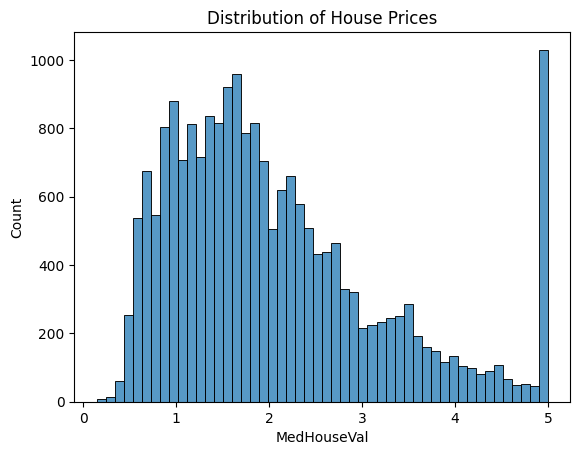

In [14]:
#Visualize 
sns.histplot(df['MedHouseVal'], bins=50)
plt.title("Distribution of House Prices")

<Axes: >

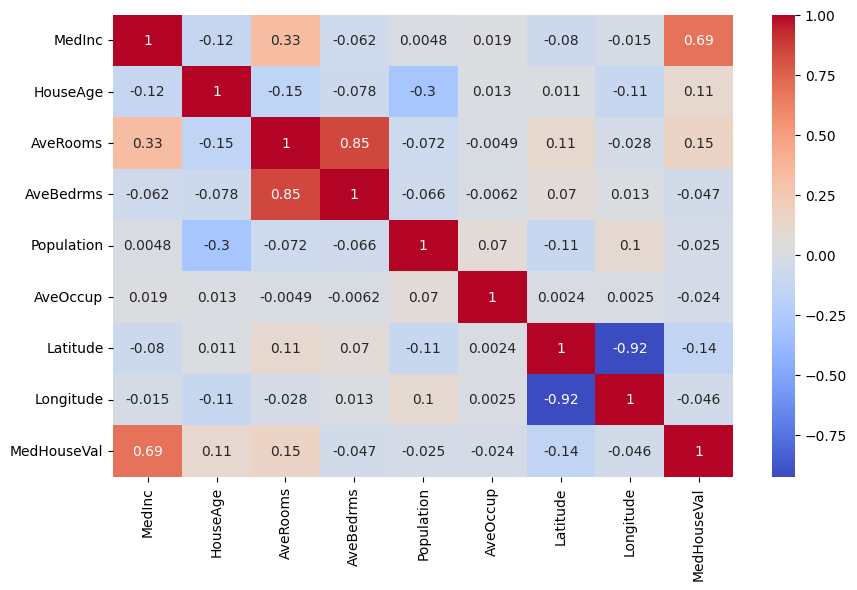

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [16]:
#Define Features and Targets
X = df[['MedInc','AveRooms','HouseAge']]
y = df['MedHouseVal']

In [17]:
#Spilt the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
#Train and Predict the Linear Regression
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [19]:
#Evaluate Performance
mse = mean_squared_error(y_test,y_pred)
print("Linear Regression MSE: ", mse)

Linear Regression MSE:  0.6589108649336336


In [20]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.49717158850807075


In [21]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

          Coefficient
MedInc       0.444758
AveRooms    -0.028150
HouseAge     0.016836


Text(0.5, 1.0, 'Actual vs Predicted House Prices')

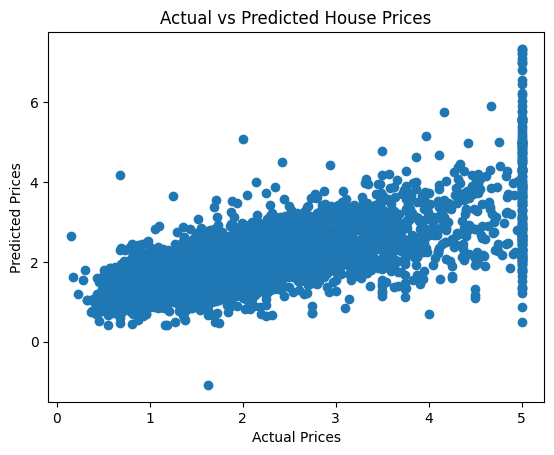

In [35]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")